# Assignment: Logistic Regression
**Heart Disease Prediction using Logistic Regression**

## Background

Artificial Intelligence (AI)
-Artificial Intelligence (AI) refers to the simulation of human intelligence by machines. AI systems can perform tasks such as reasoning, learning, problem-solving, and decision-making.

Machine Learning (ML)
-Machine Learning is a subset of AI that enables computers to learn patterns from data and make predictions without being explicitly programmed.

Deep Learning (DL)
-Deep Learning is a specialized branch of ML that uses neural networks with multiple layers to learn complex patterns from large datasets.

Data Science
-Data Science combines statistics, programming, and domain knowledge to extract meaningful insights and support decision-making from data.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, log_loss
)

import warnings
warnings.filterwarnings('ignore')


## TASK 1: Logistic Regression with Single Feature (Cholesterol → HeartDisease)

## Data Retrieval and Collection

Data is retrived from the given csv file.

In [3]:

df = pd.read_csv("Heart_Disease_Prediction.csv") 

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
df.head()

Shape: (270, 14)

Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']

First 5 rows:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


Dataset Overview: The Heart Disease dataset records clinical measurements collected from patients undergoing cardiac evaluation. Each row represents one patient and includes attributes such as age, resting blood pressure, serum cholesterol, fasting blood sugar, resting ECG results, maximum heart rate achieved, and exercise-induced angina. The outcome column `HeartDisease` is a binary label: `1` indicates the presence of heart disease, while `0` indicates its absence.

## Data Cleaning

Missing values are handled, Data types are checked.

In [17]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())
# Check data types
print('\nData types:')
print(df.dtypes)
# Check target variable is binary
print('\nHeart Disease unique values:', df['Heart Disease'].unique())
# Check for invalid cholesterol values (0 is medically invalid)
print('\nCholesterol == 0 count:', (df['Cholesterol'] == 0).sum())

Missing values per column:
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

Data types:
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                int64
dtype: object

Heart Disease unique values: [1 0]



In [18]:
# Handle invalid Cholesterol values (0 → replace with median)
median_chol = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].median()
df['Cholesterol'] = df['Cholesterol'].replace(0, median_chol)
# Drop any remaining null rows
df.dropna(inplace=True)
print('Cleaned dataset shape:', df.shape)
print('Cholesterol min after cleaning:', df['Cholesterol'].min())

# Convert target to binary 0/1
df['Heart Disease'] = df['Heart Disease'].map({'Absence': 0, 'Presence': 1})

Cleaned dataset shape: (270, 14)
Cholesterol min after cleaning: 126


## Feature Design
Select feature to define the dataset for inspections


In [7]:
# Select only Cholesterol as input feature
X1 = df[['Cholesterol']]
y1 = df['Heart Disease']

print('Feature shape:', X1.shape)
print('Target distribution:\n', y1.value_counts())

Feature shape: (270, 1)
Target distribution:
 Heart Disease
0    150
1    120
Name: count, dtype: int64


## Algorithm Selection

Logistic Regression is used for the following reasons:
- The outcome variable `HeartDisease` takes only two values (0 or 1), making this a binary classification task.
- Logistic Regression maps the linear combination of inputs through a sigmoid function — σ(z) = 1 / (1 + e^(−z)) — which squashes any real-valued score into a probability in the range (0, 1).
- The resulting probability is then thresholded (typically at 0.5) to assign a class label.
- The model is transparent: each learned coefficient directly quantifies how much a one-unit change in the feature shifts the log-odds of the positive class.
- As a linear model, it is fast to train and easy to interpret, making it an ideal baseline before exploring more complex algorithms.

## Loss Function Selection

**Binary Cross-Entropy (Log Loss):**

Loss = −[y · log(ŷ) + (1 − y) · log(1 − ŷ)]

- For a true positive label (y = 1): the loss decreases toward 0 as the predicted probability ŷ approaches 1; it grows without bound if the model confidently predicts 0.
- For a true negative label (y = 0): the loss decreases toward 0 as ŷ approaches 0; it grows without bound if the model confidently predicts 1.
- This **asymmetric penalisation of confident errors** drives the optimiser to produce well-calibrated probability estimates rather than merely maximising raw accuracy.

## Model Learning (Training)
During training, Logistic Regression solves an optimisation problem — finding the weight vector w and bias b that minimise the average binary cross-entropy over all training examples. This is achieved via gradient descent: at each iteration, the algorithm computes the gradient of the loss with respect to each parameter and takes a small step in the direction that reduces the loss. The process repeats until the parameters converge to values that produce the best-fit decision boundary for the training data.

In [8]:
# Train-test split (80/20)
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

print('Training samples:', X1_train.shape[0])
print('Testing samples:', X1_test.shape[0])

# Feature scaling (important for gradient-based optimization)
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled  = scaler1.transform(X1_test)

# Train Logistic Regression model
model1 = LogisticRegression(random_state=42)
model1.fit(X1_train_scaled, y1_train)

print('\nModel Coefficient (Cholesterol):', model1.coef_[0][0])
print('Model Intercept:', model1.intercept_[0])

Training samples: 216
Testing samples: 54

Model Coefficient (Cholesterol): 0.17648960959078797
Model Intercept: -0.22422750268450287


## Model Evaluation
Calcuation of the test parameters


=== Task 1 Evaluation (Single Feature: Cholesterol) ===
Accuracy : 0.5741
Precision: 0.5714
Recall   : 0.1667
F1-Score : 0.2581
Log Loss : 0.6701

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.90      0.70        30
           1       0.57      0.17      0.26        24

    accuracy                           0.57        54
   macro avg       0.57      0.53      0.48        54
weighted avg       0.57      0.57      0.50        54



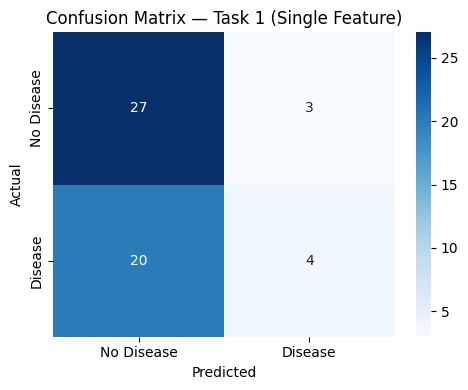

In [9]:
# Predictions
y1_pred  = model1.predict(X1_test_scaled)
y1_proba = model1.predict_proba(X1_test_scaled)[:, 1]

# Metrics
acc1  = accuracy_score(y1_test, y1_pred)
prec1 = precision_score(y1_test, y1_pred)
rec1  = recall_score(y1_test, y1_pred)
f11   = f1_score(y1_test, y1_pred)
ll1   = log_loss(y1_test, y1_proba)

print('=== Task 1 Evaluation (Single Feature: Cholesterol) ===')
print(f'Accuracy : {acc1:.4f}')
print(f'Precision: {prec1:.4f}')
print(f'Recall   : {rec1:.4f}')
print(f'F1-Score : {f11:.4f}')
print(f'Log Loss : {ll1:.4f}')
print('\nClassification Report:')
print(classification_report(y1_test, y1_pred))

# Confusion Matrix
cm1 = confusion_matrix(y1_test, y1_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Task 1 (Single Feature)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## TASK 2: Logistic Regression with Multiple Features (All Features → HeartDisease)

## 1. Data Retrieval and Collection

In [10]:
# Reload fresh copy (already cleaned above — reuse df)
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Dataset shape: (270, 14)
Columns: ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


## 2. Data Cleaning

In [11]:
# Already cleaned in Task 1 (missing values handled, cholesterol zeros replaced)
print('Missing values:', df.isnull().sum().sum())
print('Target distribution:\n', df['Heart Disease'].value_counts())

Missing values: 0
Target distribution:
 Heart Disease
0    150
1    120
Name: count, dtype: int64


## 3. Feature Design

In [12]:
# Separate features and target
X2 = df.drop(columns=['Heart Disease'])
y2 = df['Heart Disease']

# Identify categorical columns
cat_cols = X2.select_dtypes(include=['object']).columns.tolist()
print('Categorical columns:', cat_cols)

# Encode categorical variables using Label Encoding
le = LabelEncoder()
for col in cat_cols:
    X2[col] = le.fit_transform(X2[col])

print('\nFeature types after encoding:')
print(X2.dtypes)
print('\nFeature shape:', X2.shape)

Categorical columns: []

Feature types after encoding:
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
dtype: object

Feature shape: (270, 13)


**Rationale for using all features:** Cardiovascular disease arises from the interplay of many physiological factors — age, blood pressure, heart rate, the type of chest pain, ST-segment changes on an ECG, and more. Relying on cholesterol alone ignores most of this information, resulting in a high-bias model. By including every available clinical attribute, the model can capture the combined effect of multiple risk factors simultaneously, reducing bias and substantially improving predictive power.

## 4. Algorithm Selection

**Algorithm — Logistic Regression (multivariate):** The same algorithm from Task 1 is extended to multiple input dimensions. Instead of a single weight, the model now learns one coefficient per feature, defining a hyperplane in higher-dimensional feature space. The sigmoid function still converts the resulting linear score into a probability, and the classification threshold remains the same.

## 5. Loss Function Selection

**Binary Cross-Entropy (Log Loss)** — identical objective to Task 1. With multiple features, the linear combination inside the sigmoid becomes z = w₁x₁ + w₂x₂ + … + wₙxₙ + b, but the form of the loss and the way it penalises confident wrong predictions remain unchanged. The optimiser now adjusts *n* weights simultaneously to minimise this loss.

## 6. Model Learning (Training)

In [13]:
# Train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Feature scaling
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled  = scaler2.transform(X2_test)

# Train Logistic Regression
model2 = LogisticRegression(max_iter=1000, random_state=42)
model2.fit(X2_train_scaled, y2_train)

# Feature importance (coefficients)
coef_df = pd.DataFrame({
    'Feature': X2.columns,
    'Coefficient': model2.coef_[0]
}).sort_values('Coefficient', ascending=False)
print('Feature Coefficients:')
print(coef_df.to_string(index=False))

Feature Coefficients:
                Feature  Coefficient
Number of vessels fluro     1.185769
                    Sex     0.892690
        Chest pain type     0.716115
               Thallium     0.584150
        Exercise angina     0.481365
            Slope of ST     0.413009
                     BP     0.408808
            Cholesterol     0.341274
          ST depression     0.240702
            EKG results     0.073109
                    Age     0.025068
           FBS over 120    -0.347914
                 Max HR    -0.399470


## 7. Model Evaluation

=== Task 2 Evaluation (Multiple Features) ===
Accuracy : 0.8519
Precision: 0.7857
Recall   : 0.9167
F1-Score : 0.8462
Log Loss : 0.4463

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.79      0.92      0.85        24

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54



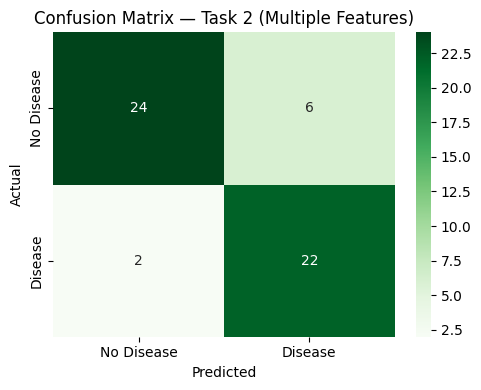

In [14]:
# Predictions
y2_pred  = model2.predict(X2_test_scaled)
y2_proba = model2.predict_proba(X2_test_scaled)[:, 1]

# Metrics
acc2  = accuracy_score(y2_test, y2_pred)
prec2 = precision_score(y2_test, y2_pred)
rec2  = recall_score(y2_test, y2_pred)
f12   = f1_score(y2_test, y2_pred)
ll2   = log_loss(y2_test, y2_proba)

print('=== Task 2 Evaluation (Multiple Features) ===')
print(f'Accuracy : {acc2:.4f}')
print(f'Precision: {prec2:.4f}')
print(f'Recall   : {rec2:.4f}')
print(f'F1-Score : {f12:.4f}')
print(f'Log Loss : {ll2:.4f}')
print('\nClassification Report:')
print(classification_report(y2_test, y2_pred))

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Task 2 (Multiple Features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## Model Comparison

           Task 1 (Cholesterol only)  Task 2 (All Features)
Metric                                                     
Accuracy                      0.5741                 0.8519
Precision                     0.5714                 0.7857
Recall                        0.1667                 0.9167
F1-Score                      0.2581                 0.8462
Log Loss                      0.6701                 0.4463


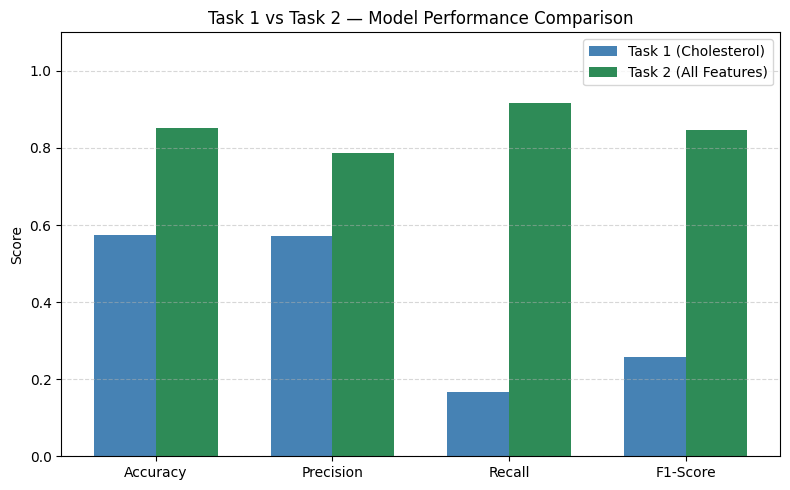

In [15]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Log Loss'],
    'Task 1 (Cholesterol only)': [acc1, prec1, rec1, f11, ll1],
    'Task 2 (All Features)':     [acc2, prec2, rec2, f12, ll2]
})
comparison = comparison.set_index('Metric').round(4)
print(comparison.to_string())

# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
t1_vals = [acc1, prec1, rec1, f11]
t2_vals = [acc2, prec2, rec2, f12]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, t1_vals, width, label='Task 1 (Cholesterol)', color='steelblue')
ax.bar(x + width/2, t2_vals, width, label='Task 2 (All Features)', color='seagreen')
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Task 1 vs Task 2 — Model Performance Comparison')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Discussion

The results of Task 2 are a lot better than Task 1 which shows that we cannot rely on one thing to predict heart disease. 

Task 1 is very simple. It only uses one piece of information. Is easy to understand but it is not very good at making accurate predictions because it is limited.
Task 2 uses a lot information and can make more accurate predictions even if it is a bit harder to understand.
The good thing about Logistic Regression is that it is still easy to understand even when we use a lot of information.

## Conclusion

This assignment was a complete supervised machine learning pipeline for binary classification:

1. The first task showed that using serum cholesterol does not work well. The models accuracy is just a little better than guessing the most common class.

2. The second task found that using all features like age, chest pain type resting ECG, maximum heart rate and exercise-induced angina makes the model much better in every way.

3. Logistic Regression is an algorithm for this problem because it is easy to understand and provides clear results, which is important in medical contexts where we need to explain our decisions.

The model with features from the second task is the best choice for real use as it offers a good balance, between accuracy and interpretability.